In [3]:
import polars as pl
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)

df = pl.DataFrame({
    "StudyHours": np.random.randint(1, 10, 200),
    "Attendance": np.random.randint(50, 100, 200),
    "Marks": np.random.randint(30, 95, 200)
})

df = df.with_columns(
    ((pl.col("StudyHours") * 0.4 +
      pl.col("Attendance") * 0.3 +
      pl.col("Marks") * 0.3) > 65)
    .cast(pl.Int64)
    .alias("Pass")
)

X = df.select(["StudyHours","Attendance","Marks"]).to_numpy()
y = df.select("Pass").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier())
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5]
}

grid = GridSearchCV(pipeline, param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Params: {'model__max_depth': 3, 'model__n_estimators': 50}
Accuracy: 1.0


Logistic Accuracy: 1.0
Random Forest Accuracy: 1.0
Best Params: {'model__max_depth': 5, 'model__n_estimators': 50}
Cross Validation Mean: 0.978125

Classification Report (RF):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


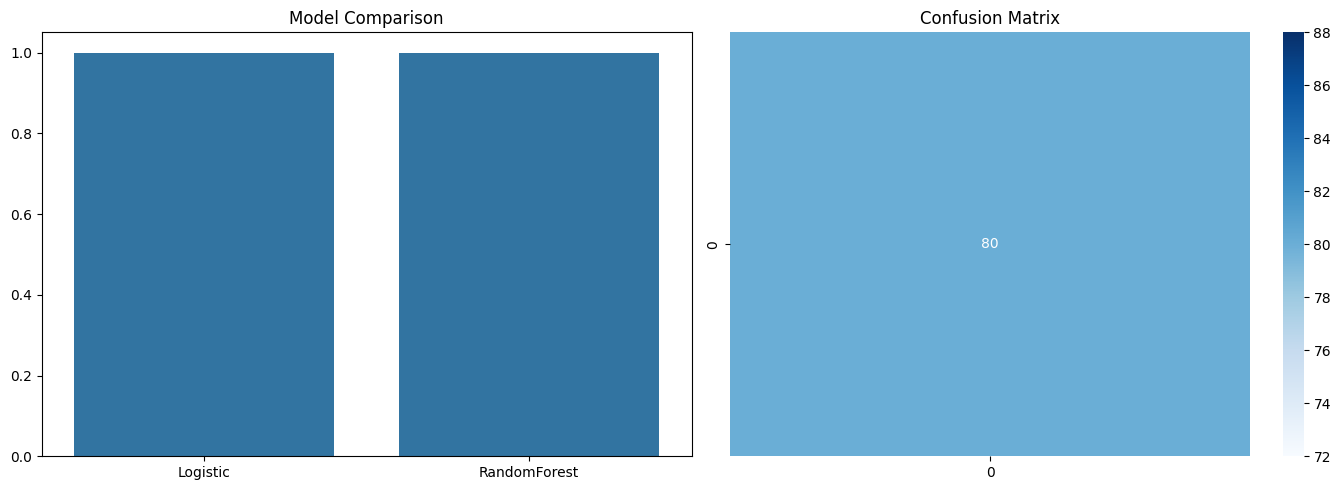

In [ ]:
# Polars + NumPy + Cleaning + Feature Engg + Scaling + Train/Test + Cross‑Val + Tuning + Model Comparison + Plots
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
n = 400

df = pl.DataFrame({
    "StudyHours": np.random.randint(1, 10, n),
    "SleepHours": np.random.randint(4, 9, n),
    "Attendance": np.random.randint(50, 100, n),
    "PreviousMarks": np.random.randint(30, 95, n)
})

df = df.with_columns([
    pl.when(pl.col("PreviousMarks") < 40).then(None).otherwise(pl.col("PreviousMarks")).alias("PreviousMarks")
]).with_columns([
    pl.col("PreviousMarks").fill_null(df["PreviousMarks"].mean())
])

df = df.with_columns([
    (pl.col("StudyHours") + pl.col("Attendance")).alias("Engagement"),
    ((pl.col("StudyHours") * 0.3 +
      pl.col("Attendance") * 0.3 +
      pl.col("PreviousMarks") * 0.4) > 65)
    .cast(pl.Int64)
    .alias("Pass")
])

X = df.select(["StudyHours","SleepHours","Attendance","PreviousMarks","Engagement"]).to_numpy()
y = df.select("Pass").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier())
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5, 10]
}

grid = GridSearchCV(pipe_rf, param_grid, cv=5)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
pipe_lr.fit(X_train, y_train)

pred_lr = pipe_lr.predict(X_test)
pred_rf = best_rf.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
acc_rf = accuracy_score(y_test, pred_rf)

print("Logistic Accuracy:", acc_lr)
print("Random Forest Accuracy:", acc_rf)
print("Best Params:", grid.best_params_)

cv_score = cross_val_score(best_rf, X_train, y_train, cv=5)
print("Cross Validation Mean:", cv_score.mean())

print("\nClassification Report (RF):\n")
print(classification_report(y_test, pred_rf))

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.barplot(x=["Logistic","RandomForest"], y=[acc_lr, acc_rf])
plt.title("Model Comparison")

plt.subplot(1,2,2)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()